In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

In [25]:
df = pd.read_csv('./Data/overall jet fuel 2008-2016.csv')
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2848 entries, 0 to 2847
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    2848 non-null   object 
 1   fuel    2848 non-null   float64
dtypes: float64(1), object(1)
memory usage: 44.6+ KB
None


,date,fuel
0,2008-05-24,320001.000000
1,2008-05-25,320001.826375
2,2008-05-26,320002.969334
3,2008-05-27,320003.513974
4,2008-05-28,320004.112301


In [26]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.sort_values("date")
# df = df.set_index("date")

In [27]:
up_to2015_df = df.loc[df['date'] <='2015-10-20']
up_to2015_df.head()

,date,fuel
0,2008-05-24,320001.000000
1,2008-05-25,320001.826375
2,2008-05-26,320002.969334
3,2008-05-27,320003.513974
4,2008-05-28,320004.112301


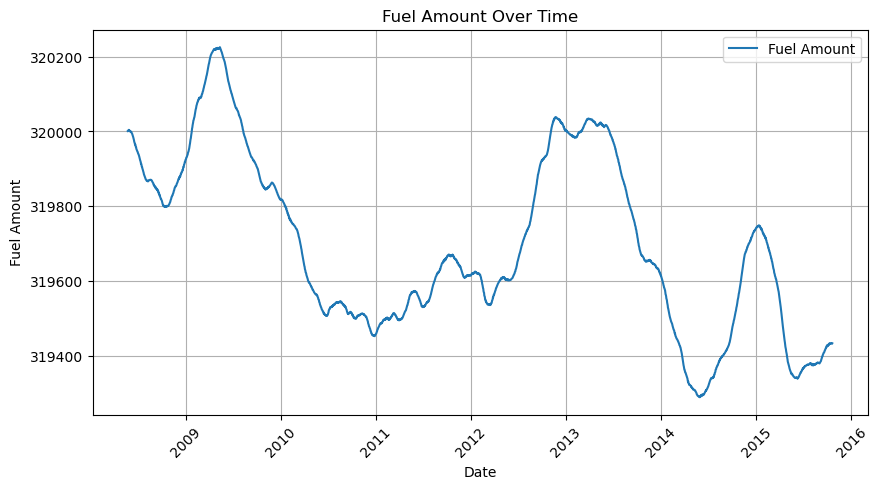

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(up_to2015_df["date"], up_to2015_df["fuel"],  label="Fuel Amount")

plt.xlabel("Date")
plt.ylabel("Fuel Amount")
plt.title("Fuel Amount Over Time")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()


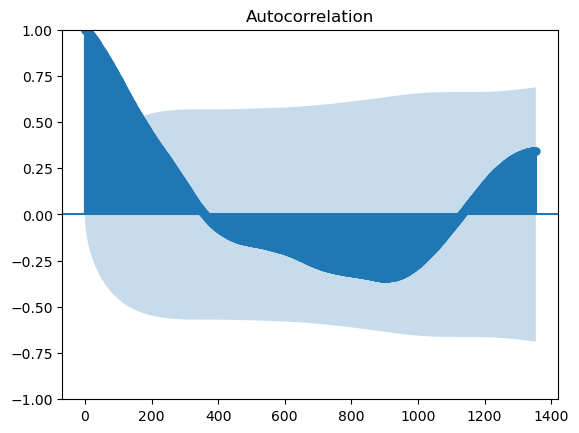

In [29]:
plot_acf(df['fuel'], lags=len(up_to2015_df)//2)
plt.show()

1. High Positive Autocorrelation at Lag 0
	•	The first bar at lag 0 is 1.0, which is expected since a series is always perfectly correlated with itself at lag 0.

2. Gradual Decrease in Autocorrelation
	•	The ACF values decrease smoothly and cross zero around lag 400.
	•	This suggests a possible trend in the data, meaning past values influence future values over a long period.

3. Negative Autocorrelation at Medium Lags (~400-800)
	•	The autocorrelation turns negative, reaching a minimum around lag 600-700.
	•	This indicates that values around 600-700 steps apart tend to be negatively correlated, meaning high values are followed by low values after that lag.

4. Potential Seasonality
	•	After reaching the negative peak, the ACF starts increasing again and becomes positive around lag 1000-1200.
	•	This suggests a possible cyclic or seasonal pattern with a periodicity of around 1200 lags.

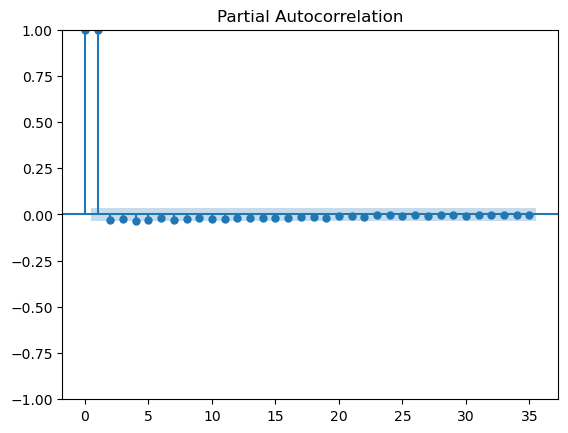

In [30]:
plot_pacf(df['fuel'])
plt.show()

In [31]:
def adf_test(series):
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("The series is stationary.")
    else:
        print("The series is non-stationary.")


adf_test(df["fuel"])

ADF Statistic: -2.2723712891039303
p-value: 0.18103364532621186
The series is non-stationary.


In [34]:
df['diff1'] = df["fuel"].diff().dropna()

In [35]:
df['diff2'] = df["diff1"].diff(1200).dropna()

ADF Statistic: -3.7837995303522534
p-value: 0.0030774847936823183
The series is stationary.


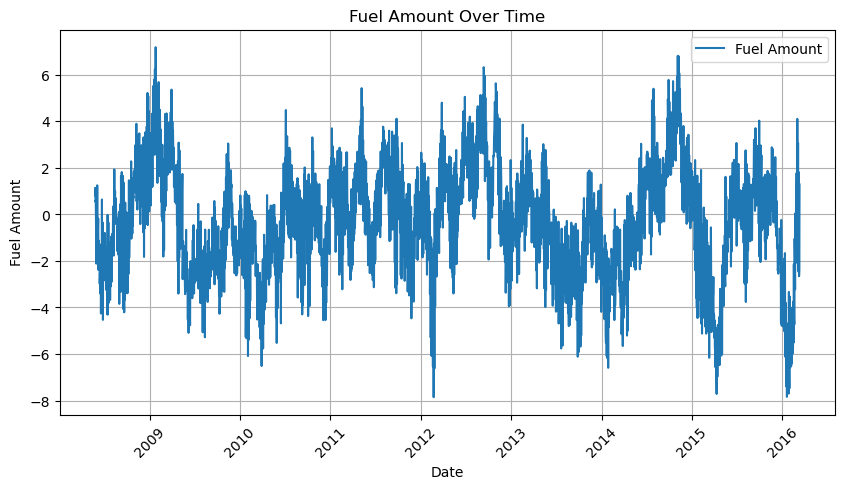

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(df["date"], (df['diff1']),  label="Fuel Amount")

plt.xlabel("Date")
plt.ylabel("Fuel Amount")
plt.title("Fuel Amount Over Time")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

adf_test(df["diff2"].dropna())

In [37]:
test_start_date = "2015-10-20"
train = df[df['date'] < test_start_date]
test = df[df['date'] >= test_start_date]

In [38]:
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA 

RMSE: 146.3392686516951


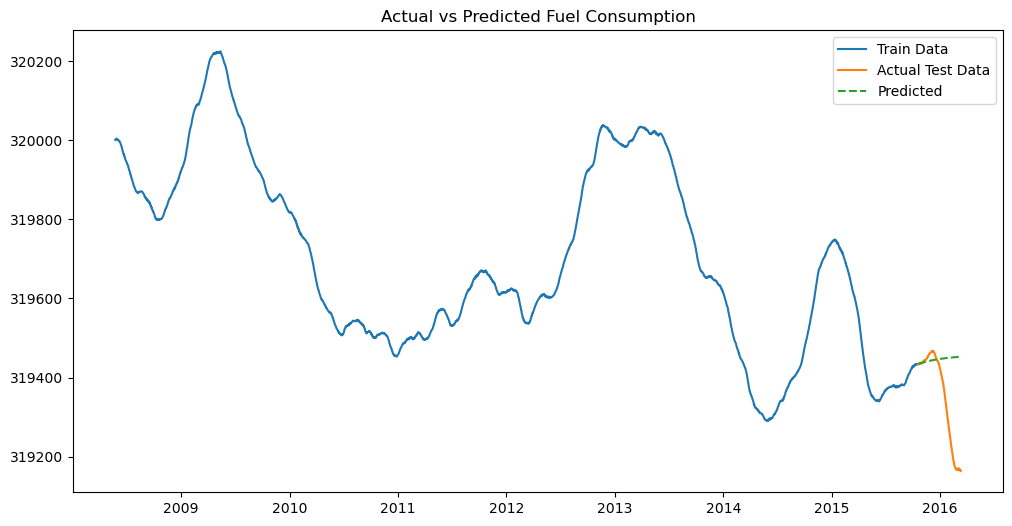

In [39]:
model = ARIMA(train["fuel"], order=(1,1,1))
model_fit = model.fit()
predictions = model_fit.forecast(steps=len(test))

rmse = np.sqrt(mean_squared_error(test["fuel"], predictions))
print(f"RMSE: {rmse}")

plt.figure(figsize=(12,6))
plt.plot(train['date'], train["fuel"], label="Train Data")
plt.plot(test['date'], test["fuel"], label="Actual Test Data")
plt.plot(test['date'], predictions, label="Predicted", linestyle="dashed")
plt.legend()
plt.title("Actual vs Predicted Fuel Consumption")
plt.show()

In [40]:
train.loc[:,"fuel_diff"] = train["fuel"].diff()
train.loc[:,"fuel_diff"] = train["fuel_diff"].diff(1200)
adf_test(train["fuel_diff"].dropna())

ADF Statistic: -4.104532052366152
p-value: 0.0009519525903003271
The series is stationary.


/var/folders/9w/ft0tywhn76j1gh647345mmy80000gn/T/ipykernel_59883/1704228882.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train.loc[:,"fuel_diff"] = train["fuel"].diff()


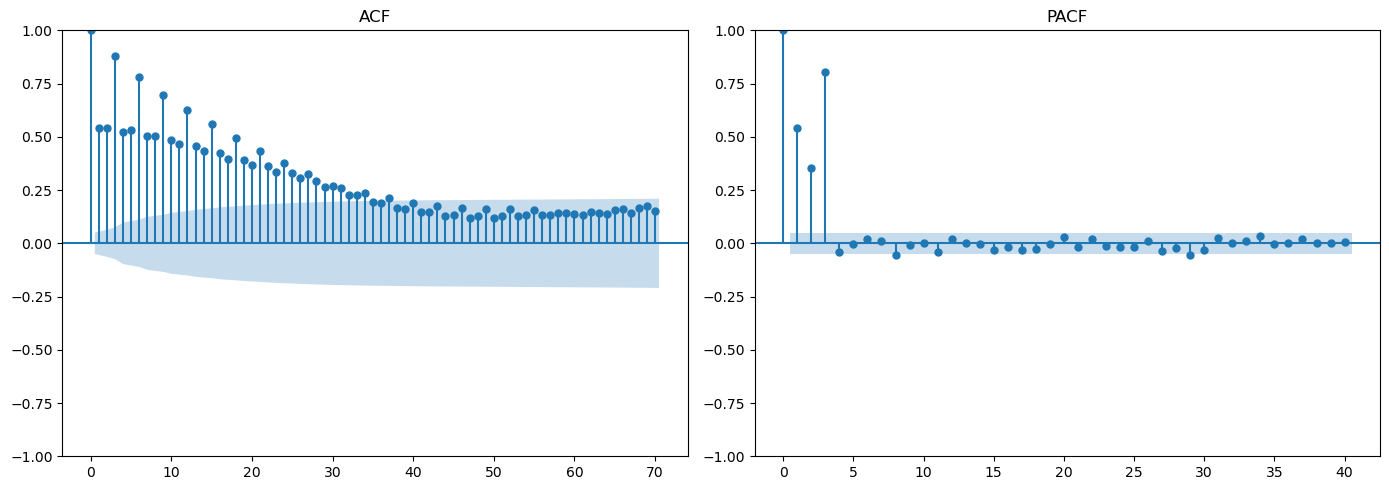

In [41]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# Plot ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(train["fuel_diff"].dropna(), ax=axes[0], lags=70, title="ACF")
plot_pacf(train["fuel_diff"].dropna(), ax=axes[1], lags=40, title="PACF")
plt.tight_layout()
plt.show()

In [42]:
test.loc[:,"fuel_diff"] = test["fuel"].diff().dropna()

/var/folders/9w/ft0tywhn76j1gh647345mmy80000gn/T/ipykernel_59883/2989704958.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:,"fuel_diff"] = test["fuel"].diff().dropna()


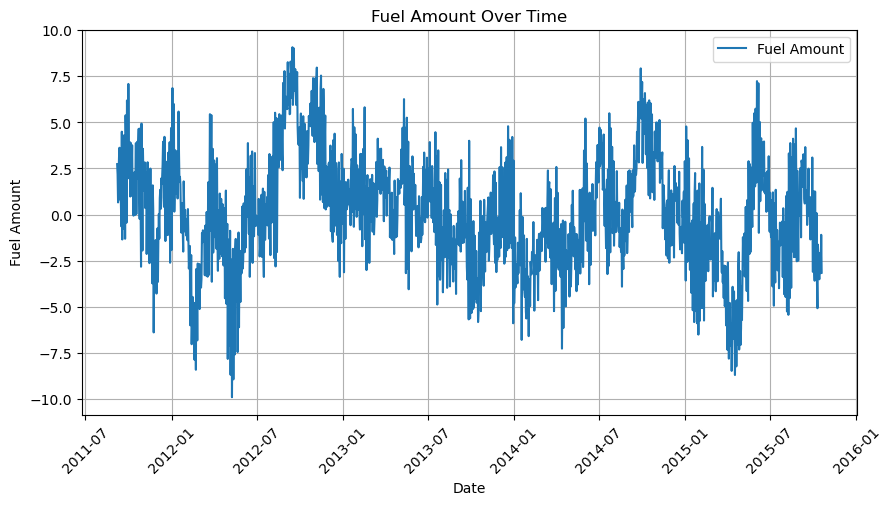

In [43]:
plt.figure(figsize=(10, 5))
plt.plot(train['date'], (train['fuel_diff']),  label="Fuel Amount")

plt.xlabel("Date")
plt.ylabel("Fuel Amount")
plt.title("Fuel Amount Over Time")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

In [44]:
auto_model = auto_arima(train['fuel_diff'].dropna(), seasonal=False, trace=True, suppress_warnings=True)
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=5381.960, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=7518.340, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=7086.396, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=6461.813, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=7516.342, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=6137.237, Time=0.15 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=5380.066, Time=0.08 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=6347.675, Time=0.07 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=5379.343, Time=0.06 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=5380.096, Time=0.07 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=5382.030, Time=0.25 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=5377.389, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=7084.402, Time=0.01 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=5378.140, Time=0.04 sec
 ARIMA(2,1,1)(0,0,0)[0]          

RMSE: 113.10359519943384


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)


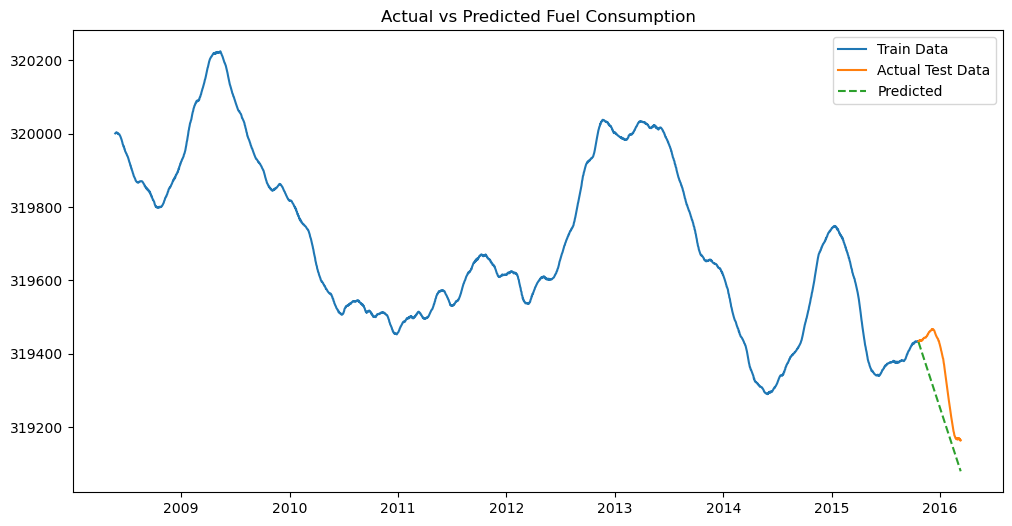

In [45]:
model = ARIMA(train["fuel_diff"].dropna(), order=(2,1,0))
model_fit = model.fit()

pred_diff = model_fit.predict(start=len(train), end=len(train) + len(test) - 1)

predictions = train["fuel"].iloc[-1] + np.cumsum(pred_diff)

rmse = np.sqrt(mean_squared_error(test["fuel"], predictions))
print(f"RMSE: {rmse}")

plt.figure(figsize=(12,6))
plt.plot(train['date'], train["fuel"], label="Train Data")
plt.plot(test['date'], test["fuel"], label="Actual Test Data")
plt.plot(test['date'], predictions, label="Predicted", linestyle="dashed")
plt.legend()
plt.title("Actual vs Predicted Fuel Consumption")
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/var/folders/9w/ft0tywhn76j1gh647345mmy80000gn/T/ipykernel_59883/2439432206.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  next_pred = model_fit.forecast(steps=1)[0]
/var/folders/9w/ft0

Dynamic Forecast RMSE: 8457.144416158124


/var/folders/9w/ft0tywhn76j1gh647345mmy80000gn/T/ipykernel_59883/2439432206.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  next_pred = model_fit.forecast(steps=1)[0]
/var/folders/9w/ft0tywhn76j1gh647345mmy80000gn/T/ipykernel_59883/2439432206.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  next_pred = model_fit.forecast(steps=1)[0]
/var/folders/9w/ft0tywhn76j1gh647345mmy80000gn/T/ipykernel_59883/2439432206.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a valu

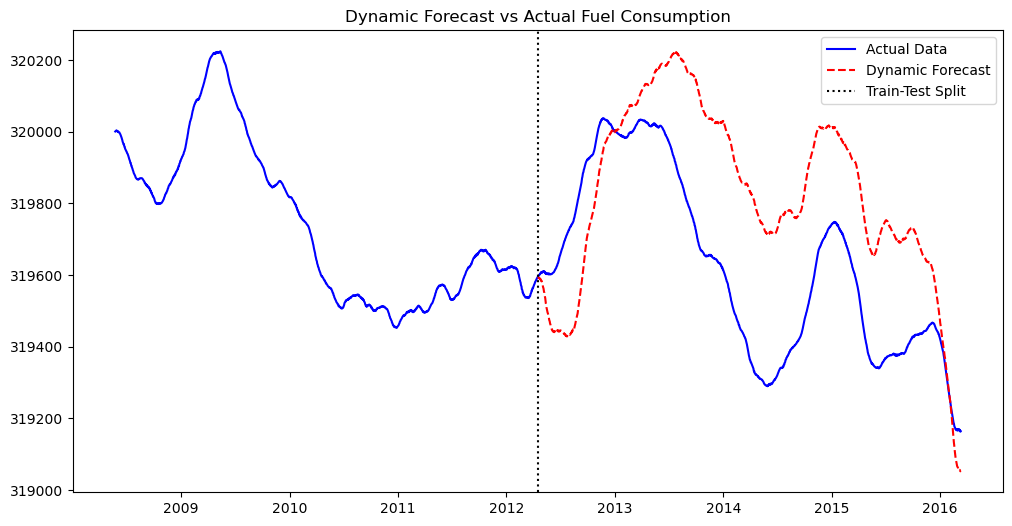

In [57]:
split_idx = int(len(df) * 0.5)
train, test = df.iloc[:split_idx].copy(), df.iloc[split_idx:].copy()

model = ARIMA(train["diff2"].dropna(), order=(2,1,0))
model_fit = model.fit()

pred_diff_dynamic = []

for t in range(len(test)):
    next_pred = model_fit.forecast(steps=1)[0]
    pred_diff_dynamic.append(next_pred)
    
    model_fit = model_fit.append([test["diff2"].iloc[t]], refit=False)

predictions_dynamic = train["fuel"].iloc[-1] + np.cumsum(pred_diff_dynamic)

rmse_dynamic = np.sqrt(mean_squared_error(test["fuel"].fillna(0), predictions_dynamic))
print(f"Dynamic Forecast RMSE: {rmse_dynamic}")

plt.figure(figsize=(12,6))
plt.plot(df['date'], df["fuel"], label="Actual Data", color="blue")
plt.plot(test['date'], predictions_dynamic, label="Dynamic Forecast", linestyle="dashed", color="red")
plt.axvline(df['date'].iloc[split_idx], color="black", linestyle="dotted", label="Train-Test Split")
plt.legend()
plt.title("Dynamic Forecast vs Actual Fuel Consumption")
plt.show()